<a href="https://colab.research.google.com/github/rauf-mifteev/Ahuntsic_AI_Optimization/blob/main/AI_TP_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intelligence Artificielle 1 — Travail Pratique 2

Optimisation : Programmation Linéaire, Glouton et Programmation Dynamique

## Partie 1 — Programmation linéaire avec PuLP

Cette première section utilise la bibliothèque PuLP pour formuler le problème mathématiquement et garantir la sélection optimale exacte des équipes.

### 1.1 Données du problème

In [36]:
joueurs = [
    {"nom": "Alice", "score": 88, "salaire": 1200, "poids": 72},
    {"nom": "Bob",   "score": 91, "salaire": 1800, "poids": 85},
    {"nom": "Clara", "score": 84, "salaire": 950,  "poids": 68},
    {"nom": "David", "score": 93, "salaire": 2100, "poids": 90},
    {"nom": "Emma",  "score": 79, "salaire": 800,  "poids": 65},
    {"nom": "Frank", "score": 87, "salaire": 2400, "poids": 95},
    {"nom": "Grace", "score": 85, "salaire": 1050, "poids": 70},
    {"nom": "Hugo",  "score": 89, "salaire": 1600, "poids": 80}
]

### 1.2 Définition du problème de maximisation

In [37]:
import pulp

prob = pulp.LpProblem("Ligue_Basketball", pulp.LpMaximize)

### 1.3 Variables de décision binaires (0 ou 1)

In [38]:
# x_A[nom] = 1 si le joueur est dans l'équipe A
x_A = pulp.LpVariable.dicts("EqA", [j["nom"] for j in joueurs], cat='Binary')
x_B = pulp.LpVariable.dicts("EqB", [j["nom"] for j in joueurs], cat='Binary')

### 1.4 Fonction objective : Maximiser le score total

In [39]:
prob += pulp.lpSum([j["score"] * (x_A[j["nom"]] + x_B[j["nom"]]) for j in joueurs]), "Score_Total"

### 1.5 Contraintes

In [40]:
# Exactement 3 joueurs par équipe
prob += pulp.lpSum([x_A[j["nom"]] for j in joueurs]) == 3, "Taille_EqA"
prob += pulp.lpSum([x_B[j["nom"]] for j in joueurs]) == 3, "Taille_EqB"

# Un joueur ne peut être que dans une seule équipe (ou aucune)
for j in joueurs:
    prob += x_A[j["nom"]] + x_B[j["nom"]] <= 1, f"Unicite_{j['nom']}"

# Budget total max de 8500$
prob += pulp.lpSum([j["salaire"] * (x_A[j["nom"]] + x_B[j["nom"]]) for j in joueurs]) <= 8500, "Budget_Total"

# Poids max de 250 Kg par équipe
prob += pulp.lpSum([j["poids"] * x_A[j["nom"]] for j in joueurs]) <= 250, "Poids_EqA"
prob += pulp.lpSum([j["poids"] * x_B[j["nom"]] for j in joueurs]) <= 250, "Poids_EqB"

### 1.6 Résolution

In [41]:
prob.solve()

1

### 1.7 Affichage des résultats

In [42]:
print(f"Statut : {pulp.LpStatus[prob.status]}\n")

equipe_A_obj, equipe_B_obj = [], []

for j in joueurs:
    if x_A[j["nom"]].varValue == 1:
        equipe_A_obj.append(j)
    elif x_B[j["nom"]].varValue == 1:
        equipe_B_obj.append(j)

score_A = sum(j["score"]   for j in equipe_A_obj)
sal_A   = sum(j["salaire"] for j in equipe_A_obj)
poids_A = sum(j["poids"]   for j in equipe_A_obj)

score_B = sum(j["score"]   for j in equipe_B_obj)
sal_B   = sum(j["salaire"] for j in equipe_B_obj)
poids_B = sum(j["poids"]   for j in equipe_B_obj)

print(f"Equipe A : {[j['nom'] for j in equipe_A_obj]}")
print(f"  Score : {score_A} pts | Salaire : {sal_A} $ | Poids : {poids_A} kg")
print(f"\nEquipe B : {[j['nom'] for j in equipe_B_obj]}")
print(f"  Score : {score_B} pts | Salaire : {sal_B} $ | Poids : {poids_B} kg")
print(f"\nScore Total Optimal  : {int(pulp.value(prob.objective))} pts")
print(f"Budget Total Utilise : {sal_A + sal_B} $ / 8 500 $")

Statut : Optimal

Equipe A : ['Clara', 'Emma', 'Hugo']
  Score : 252 pts | Salaire : 3350 $ | Poids : 213 kg

Equipe B : ['Alice', 'Bob', 'David']
  Score : 272 pts | Salaire : 5100 $ | Poids : 247 kg

Score Total Optimal  : 524 pts
Budget Total Utilise : 8450 $ / 8 500 $


## Partie 2 — Algorithme glouton
Cette section explore trois stratégies gloutonnes pour former les équipes rapidement, afin de comparer l'efficacité de ces choix locaux avec la solution mathématique optimale. En gardant les même données 'joueurs' que dans la partie 1

In [43]:
def verifier_contraintes(equipe, nouveau_joueur, budget_restant):
    """Fonction modulaire pour vérifier si un joueur peut être ajouté."""
    poids_actuel = sum(j["poids"] for j in equipe)
    if len(equipe) >= 3:
        return False
    if poids_actuel + nouveau_joueur["poids"] > 250:
        return False
    if nouveau_joueur["salaire"] > budget_restant:
        return False
    return True

def algorithme_glouton(joueurs_dispo, strategie_tri):
    """Exécute l'algorithme glouton basé sur une clé de tri spécifique."""
    # Trier les joueurs selon la stratégie
    joueurs_tries = sorted(joueurs_dispo, key=strategie_tri, reverse=True)

    equipe_A, equipe_B = [], []
    budget_restant = 8500

    for joueur in joueurs_tries:
        # Tenter d'ajouter à l'équipe A d'abord
        if verifier_contraintes(equipe_A, joueur, budget_restant):
            equipe_A.append(joueur)
            budget_restant -= joueur["salaire"]
        # Sinon, tenter d'ajouter à l'équipe B
        elif verifier_contraintes(equipe_B, joueur, budget_restant):
            equipe_B.append(joueur)
            budget_restant -= joueur["salaire"]

    # Vérification finale
    if len(equipe_A) < 3 or len(equipe_B) < 3:
        print("Erreur : Impossible de remplir les équipes avec ces contraintes.")

    score_total = sum(j["score"] for j in equipe_A + equipe_B)
    budget_utilise = 8500 - budget_restant
    return equipe_A, equipe_B, score_total, budget_utilise

### Stratégie 1: Meilleur score absolu

In [44]:
print("--- Stratégie 1 : Meilleur score ---")
eqA1, eqB1, score1, budget1 = algorithme_glouton(joueurs, lambda j: j["score"])
print(f"Équipes: {[j['nom'] for j in eqA1]} | {[j['nom'] for j in eqB1]}")
print(f"Score: {score1}, Budget: {budget1}$\n")

--- Stratégie 1 : Meilleur score ---
Erreur : Impossible de remplir les équipes avec ces contraintes.
Équipes: ['David', 'Bob', 'Alice'] | ['Hugo', 'Grace']
Score: 446, Budget: 7750$



### Stratégie 2: Meilleur ratio score/salaire

In [45]:
print("--- Stratégie 2 : Meilleur ratio score/salaire ---")
eqA2, eqB2, score2, budget2 = algorithme_glouton(joueurs, lambda j: j["score"] / j["salaire"])
print(f"Équipes: {[j['nom'] for j in eqA2]} | {[j['nom'] for j in eqB2]}")
print(f"Score: {score2}, Budget: {budget2}$\n")

--- Stratégie 2 : Meilleur ratio score/salaire ---
Équipes: ['Emma', 'Clara', 'Grace'] | ['Alice', 'Hugo', 'Bob']
Score: 516, Budget: 7400$



### Stratégie 3: Meilleur ratio score/poids

In [46]:
print("--- Stratégie 3 : Meilleur ratio score/poids ---")
eqA3, eqB3, score3, budget3 = algorithme_glouton(joueurs, lambda j: j["score"] / j["poids"])
print(f"Équipes: {[j['nom'] for j in eqA3]} | {[j['nom'] for j in eqB3]}")
print(f"Score: {score3}, Budget: {budget3}$\n")

--- Stratégie 3 : Meilleur ratio score/poids ---
Équipes: ['Clara', 'Alice', 'Emma'] | ['Grace', 'Hugo', 'Bob']
Score: 516, Budget: 7400$



### Tableau comparatif des stratégies gloutonnes vs PuLP

In [47]:
score_optimal = int(pulp.value(prob.objective))
valide1 = len(eqA1) == 3 and len(eqB1) == 3

lignes = [
    ("Strategie 1 (score absolu)",  score1 if valide1 else None, budget1 if valide1 else None),
    ("Strategie 2 (score/salaire)", score2, budget2),
    ("Strategie 3 (score/poids)",   score3, budget3),
    ("PuLP (optimal)",              score_optimal, sal_A + sal_B),
]

print(f"{'Approche':<32} {'Score':>8} {'Budget':>10}  {'Ecart vs PuLP':>22}")
print("-" * 76)

for nom, score, budget in lignes:
    if score is None:
        print(f"{nom:<32} {'Echec':>8} {'N/A':>10}  {'Equipes incompletes':>22}")
    elif nom == "PuLP (optimal)":
        print(f"{nom:<32} {score:>8} {str(budget) + ' $':>10}  {'---':>22}")
    else:
        ecart = score - score_optimal
        ecart_pct = ecart / score_optimal * 100
        ecart_str = f"{ecart:+d} pts ({ecart_pct:+.1f} %)"
        print(f"{nom:<32} {score:>8} {str(budget) + ' $':>10}  {ecart_str:>22}")

Approche                            Score     Budget           Ecart vs PuLP
----------------------------------------------------------------------------
Strategie 1 (score absolu)          Echec        N/A     Equipes incompletes
Strategie 2 (score/salaire)           516     7400 $         -8 pts (-1.5 %)
Strategie 3 (score/poids)             516     7400 $         -8 pts (-1.5 %)
PuLP (optimal)                        524     8450 $                     ---


## Partie 3 — Récursivité et programmation dynamique

Cette section met de côté les contraintes de la ligue pour se concentrer uniquement sur les concepts de récursivité et de programmation dynamique.

### 3.1  Score cumulé récursif

In [48]:
# Trier la liste une seule fois à l'extérieur de la fonction
joueurs_tries = sorted(joueurs, key=lambda j: j["score"], reverse=True)

def score_cumule(joueurs_liste, k):
    """Calcule le score total des k meilleurs joueurs de façon récursive."""
    # Cas d'arrêt (Base case)
    if k == 0:
        print("score_cumule(joueurs, 0) = 0")
        return 0

    # Appel récursif (Recursive step)
    score_precedent = score_cumule(joueurs_liste, k-1)

    # Récupération du joueur actuel (k-1 car les index commencent à 0)
    joueur_actuel = joueurs_liste[k-1]
    score_total = joueur_actuel["score"] + score_precedent

    # Affichage de l'étape actuelle
    print(f"score_cumule(joueurs, {k}) = {score_precedent} + {joueur_actuel['score']} ({joueur_actuel['nom']}) = {score_total}")

    return score_total

# --- Test de la fonction ---
print("--- Score Cumulé : étapes pour les", len(joueurs_tries), "joueurs ---")
score_cumule(joueurs_tries, len(joueurs_tries))

--- Score Cumulé : étapes pour les 8 joueurs ---
score_cumule(joueurs, 0) = 0
score_cumule(joueurs, 1) = 0 + 93 (David) = 93
score_cumule(joueurs, 2) = 93 + 91 (Bob) = 184
score_cumule(joueurs, 3) = 184 + 89 (Hugo) = 273
score_cumule(joueurs, 4) = 273 + 88 (Alice) = 361
score_cumule(joueurs, 5) = 361 + 87 (Frank) = 448
score_cumule(joueurs, 6) = 448 + 85 (Grace) = 533
score_cumule(joueurs, 7) = 533 + 84 (Clara) = 617
score_cumule(joueurs, 8) = 617 + 79 (Emma) = 696


696

### 3.2 Fibonacci des scores (Naïf vs Mémoïsé)

In [49]:
import time

# Les valeurs de départ proviennent des deux meilleurs joueurs de PuLP
FIB_0 = 93 # David
FIB_1 = 91 # Bob

def fib_naif(n):
    """Calcule Fibonacci sans mémorisation (très lent pour les grands n)."""
    if n == 0:
        return FIB_0
    if n == 1:
        return FIB_1
    return fib_naif(n-1) + fib_naif(n-2)

memo = {}

def fib_memo(n):
    """Calcule Fibonacci avec mémorisation (Programmation Dynamique)."""
    if n in memo:
        return memo[n]

    if n == 0:
        resultat = FIB_0
    elif n == 1:
        resultat = FIB_1
    else:
        resultat = fib_memo(n-1) + fib_memo(n-2)

    memo[n] = resultat
    return resultat

# --- Mesure des temps d'exécution ---
n_test = 35
print(f"--- Comparaison Fibonacci pour n={n_test} ---")

# Test Naïf
debut_naif = time.perf_counter()
res_naif = fib_naif(n_test)
fin_naif = time.perf_counter()
print(f"fib_naif({n_test}) = {res_naif}")
print(f"Temps naïf: {fin_naif - debut_naif:.6f}s")

# Test Mémoïsé
debut_memo = time.perf_counter()
res_memo = fib_memo(n_test)
fin_memo = time.perf_counter()
print(f"fib_memo({n_test}) = {res_memo}")
print(f"Temps mémoïsé: {fin_memo - debut_memo:.6f}s")

--- Comparaison Fibonacci pour n=35 ---
fib_naif(35) = 1370067806
Temps naïf: 2.223114s
fib_memo(35) = 1370067806
Temps mémoïsé: 0.000088s


## Partie 4 — Graphiques d’analyse

### 4.1 Comparaison des algorithmes (Barres)
**Description :** Ce graphique à barres compare visuellement le score total obtenu par chaque approche gloutonne par rapport au score optimal calculé par la programmation linéaire (PuLP).

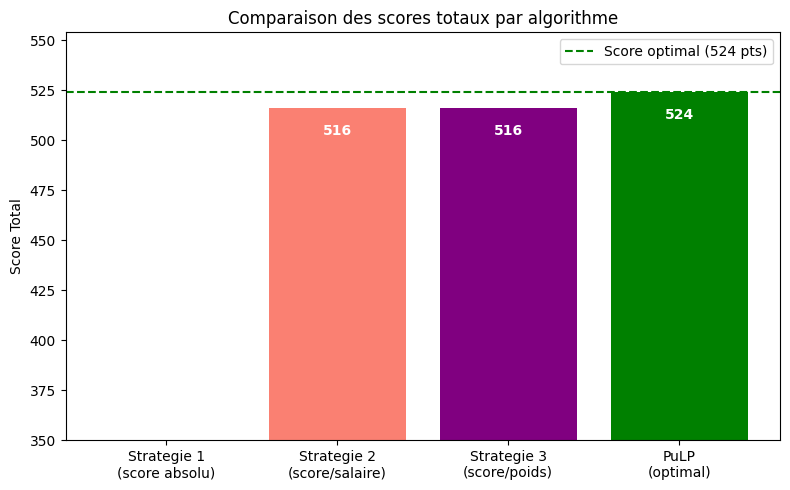

In [50]:
import matplotlib.pyplot as plt

# Les données calculées dans les parties précédentes
valide1 = len(eqA1) == 3 and len(eqB1) == 3

scores_algo = {
    "Strategie 1\n(score absolu)":  score1 if valide1 else 0,
    "Strategie 2\n(score/salaire)": score2,
    "Strategie 3\n(score/poids)":   score3,
    "PuLP\n(optimal)":              score_optimal,
}

noms    = list(scores_algo.keys())
valeurs = list(scores_algo.values())

fig, ax = plt.subplots(figsize=(8, 5))
couleurs = ['steelblue', 'salmon', 'purple', 'green']
barres = ax.bar(noms, valeurs, color=couleurs)

ax.axhline(y=score_optimal, color="green", linestyle="--",
           label=f"Score optimal ({score_optimal} pts)")
ax.set_title("Comparaison des scores totaux par algorithme")
ax.set_ylabel("Score Total")
ax.set_ylim(350, score_optimal + 30)
ax.legend()

for barre, (nom, val) in zip(barres, scores_algo.items()):
    est_echec = "Strategie 1" in nom and not valide1
    label = "Echec" if est_echec else str(val)
    ax.text(barre.get_x() + barre.get_width() / 2.,
            max(barre.get_height() - 15, 360),
            label, ha="center", va="bottom", color="white", fontweight="bold")

plt.tight_layout()
plt.show()

**Analyse :**
Le graphique met en évidence les différences entre les stratégies gloutonnes et la solution optimale de PuLP. La Stratégie 1 (tri par score absolu) échoue à constituer deux équipes complètes : en sélectionnant en premier les joueurs aux scores les plus élevés (et donc les plus coûteux), elle épuise le budget avant de pouvoir placer un troisième joueur dans l'équipe B. Les Stratégies 2 et 3, basées sur des ratios, forment des équipes valides et atteignent 516 pts, soit un écart de seulement 8 points (−1,5 %) par rapport à l'optimum de PuLP (524 pts). Ce résultat illustre bien que le choix du critère glouton peut faire la différence entre un échec complet et une solution proche de l'optimal.

### 4.2 Croissance du nombre d'appels récursifs (Courbe logarithmique)
**Description :** Ce graphique illustre la différence fondamentale de complexité temporelle entre la récursivité naïve et la programmation dynamique (mémoïsation). Il trace le nombre d'appels nécessaires pour calculer la suite de Fibonacci pour des valeurs de $n$ allant de 1 à 25. Une échelle logarithmique est utilisée en Y.

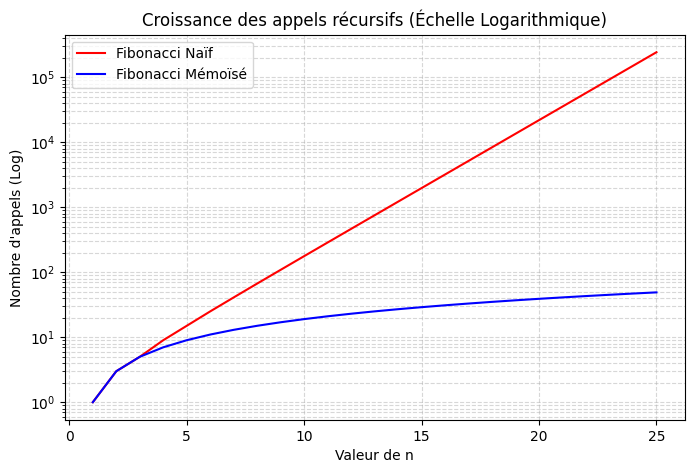

In [51]:
compteur = {"naif": 0, "memo": 0}
memo_graph = {}

def fib_naif_count(n):
    compteur["naif"] += 1
    if n <= 1: return n
    return fib_naif_count(n-1) + fib_naif_count(n-2)

def fib_memo_count(n):
    compteur["memo"] += 1
    if n in memo_graph: return memo_graph[n]
    if n <= 1:
        resultat = n
    else:
        resultat = fib_memo_count(n-1) + fib_memo_count(n-2)
    memo_graph[n] = resultat
    return resultat

# Collecte des données
n_valeurs = list(range(1, 26))
appels_naif = []
appels_memo = []

for n in n_valeurs:
    compteur["naif"] = 0
    compteur["memo"] = 0
    memo_graph.clear()

    fib_naif_count(n)
    fib_memo_count(n)

    appels_naif.append(compteur["naif"])
    appels_memo.append(compteur["memo"])

# Création du graphique
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_valeurs, appels_naif, color='red', label='Fibonacci Naïf')
ax.plot(n_valeurs, appels_memo, color='blue', label='Fibonacci Mémoïsé')

# Échelle logarithmique cruciale
ax.set_yscale('log')

# Formatage
ax.set_title("Croissance des appels récursifs (Échelle Logarithmique)")
ax.set_xlabel("Valeur de n")
ax.set_ylabel("Nombre d'appels (Log)")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

**Analyse :**
Ce graphique à échelle logarithmique rend visuellement évidente la différence de complexité algorithmique (Big O). La courbe rouge (naïve) est une ligne droite ascendante sur une échelle log, ce qui prouve une croissance exponentielle de type $O(2^n)$. Chaque incrémentation de $n$ double presque le temps de calcul. À l'inverse, la courbe bleue (mémoïsée) s'aplatit considérablement, car les sous-problèmes déjà résolus sont stockés en mémoire. Cela explique parfaitement nos mesures de temps pour $n=35$ (partie 3.2) : la version naïve a mis plus de 2.22 secondes en saturant le processeur, tandis que la version avec programmation dynamique s'est exécutée en une fraction de milliseconde (0.000085s).

### 4.3 Répartition du budget et du poids par équipe (Barres groupées)
**Description :** Ce graphique vérifie visuellement si la solution optimale respecte les contraintes imposées par la ligue (budget maximum de 8500$ et poids maximum de 250 Kg par équipe).

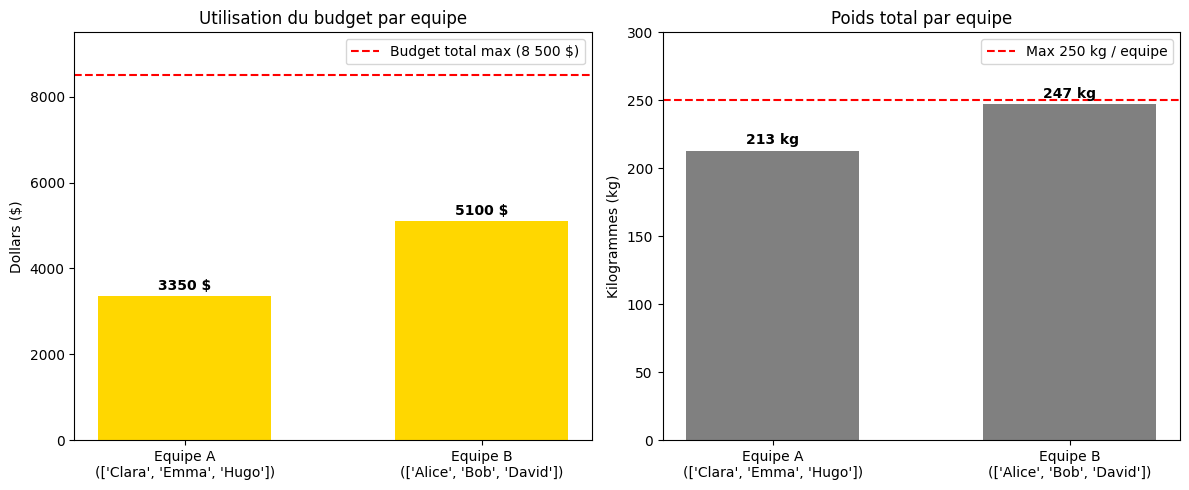

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Les données depuis la Partie 1
budget_A_pulp = sum(j["salaire"] for j in equipe_A_obj)
poids_A_pulp  = sum(j["poids"]   for j in equipe_A_obj)
budget_B_pulp = sum(j["salaire"] for j in equipe_B_obj)
poids_B_pulp  = sum(j["poids"]   for j in equipe_B_obj)

budgets = [budget_A_pulp, budget_B_pulp]
poids_vals = [poids_A_pulp, poids_B_pulp]
noms_eq = [
    f"Equipe A\n({[j['nom'] for j in equipe_A_obj]})",
    f"Equipe B\n({[j['nom'] for j in equipe_B_obj]})",
]

x = np.array([0, 0.6])
largeur = 0.35
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Budget ---
ax1.bar(x, budgets, largeur, color="gold")
ax1.axhline(y=8500, color="red", linestyle="--", label="Budget total max (8 500 $)")
ax1.set_title("Utilisation du budget par equipe")
ax1.set_ylabel("Dollars ($)")
ax1.set_ylim(0, 9500)
ax1.set_xticks(x)
ax1.set_xticklabels(noms_eq)
for i, v in zip(x, budgets):
    ax1.text(i, v + 150, f"{v} $", ha="center", fontweight="bold")
ax1.legend()

# --- Poids ---
ax2.bar(x, poids_vals, largeur, color="gray")
ax2.axhline(y=250, color="red", linestyle="--", label="Max 250 kg / equipe")
ax2.set_title("Poids total par equipe")
ax2.set_ylabel("Kilogrammes (kg)")
ax2.set_ylim(0, 300)
ax2.set_xticks(x)
ax2.set_xticklabels(noms_eq)
for i, v in zip(x, poids_vals):
    ax2.text(i, v + 5, f"{v} kg", ha="center", fontweight="bold")
ax2.legend()

plt.tight_layout()
plt.show()

**Analyse :**
Ce graphique montre de façon simple que la solution de PuLP respecte bien toutes les règles de la ligue. D'abord, le budget total dépensé pour les six joueurs est de 8050 dollars (3350 + 5100). C'est parfait, car c'est moins que le maximum autorisé de 8500 $.

Ensuite, on voit très bien comment l'algorithme fait son travail d'optimisation en regardant le poids de l'Équipe B. Cette équipe pèse 247 Kg au total. C'est extrêmement proche de la limite de 250 Kg. Cela prouve que PuLP a calculé la meilleure combinaison possible : il a réussi à regrouper les joueurs qui marquent le plus de points (Alice, Bob et David), tout en s'arrêtant juste avant de dépasser le poids maximum.

### 4.4 Profil des joueurs sélectionnés (Données normalisées)
**Description :** Pour comprendre l'équilibre de la sélection optimale, ce graphique compare le score, le salaire et le poids des joueurs choisis par PuLP. Les données sont normalisées entre 0 et 1 pour permettre une comparaison directe d'unités totalement différentes (points, dollars, kilos).

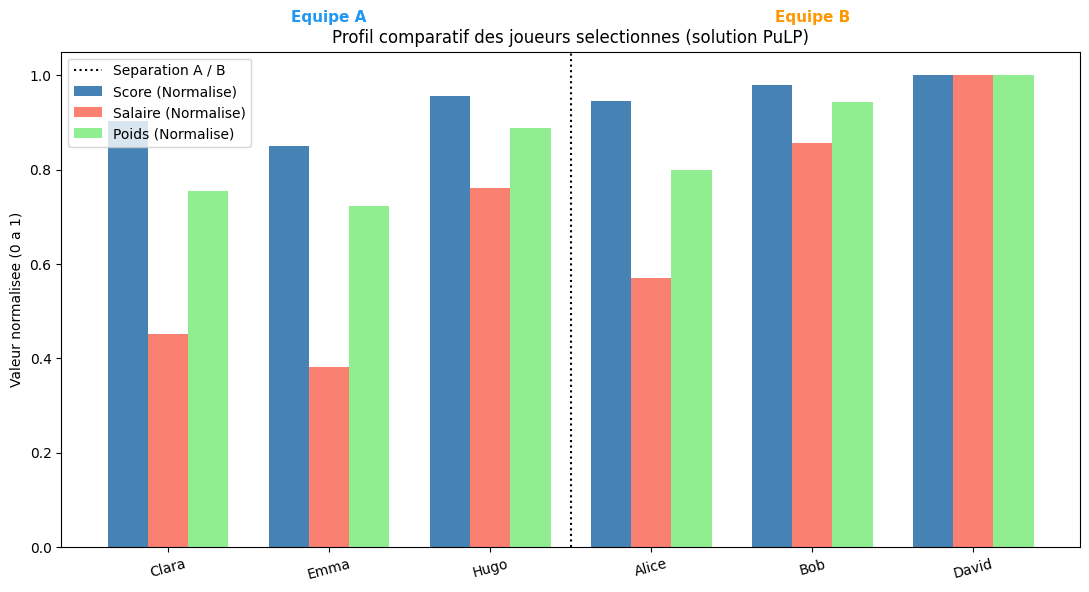

In [53]:
# Les données depuis la Partie 1
joueurs_selectionnes = equipe_A_obj + equipe_B_obj
noms_j     = [j["nom"]     for j in joueurs_selectionnes]
scores_j   = [j["score"]   for j in joueurs_selectionnes]
salaires_j = [j["salaire"] for j in joueurs_selectionnes]
poids_j    = [j["poids"]   for j in joueurs_selectionnes]

def normaliser(liste):
    val_max = max(liste)
    return [v / val_max for v in liste] if val_max > 0 else [0] * len(liste)

scores_norm   = normaliser(scores_j)
salaires_norm = normaliser(salaires_j)
poids_norm    = normaliser(poids_j)

x_j = np.arange(len(noms_j))
w   = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x_j - w, scores_norm,   w, label="Score (Normalise)",   color="steelblue")
ax.bar(x_j,     salaires_norm, w, label="Salaire (Normalise)", color="salmon")
ax.bar(x_j + w, poids_norm,    w, label="Poids (Normalise)",   color="lightgreen")

# Ligne de séparation visuelle entre équipe A et équipe B
ax.axvline(x=len(equipe_A_obj) - 0.5, color="black", linestyle=":", linewidth=1.5,
           label="Separation A / B")

ax.set_title("Profil comparatif des joueurs selectionnes (solution PuLP)")
ax.set_xticks(x_j)
ax.set_xticklabels(noms_j, rotation=15)
ax.set_ylabel("Valeur normalisee (0 a 1)")
ax.legend()

# Annotations équipes
mid_A = (len(equipe_A_obj) - 1) / 2
mid_B = len(equipe_A_obj) + (len(equipe_B_obj) - 1) / 2
ax.text(mid_A, 1.06, "Equipe A", ha="center", fontsize=11,
        fontweight="bold", color="#2196F3", transform=ax.get_xaxis_transform())
ax.text(mid_B, 1.06, "Equipe B", ha="center", fontsize=11,
        fontweight="bold", color="#FF9800", transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.show()

**Analyse :**
La normalisation des données nous permet d'analyser l'arbitrage fait par l'algorithme d'optimisation. Le graphique met en évidence comment PuLP a équilibré des profils asymétriques. Par exemple, un joueur peut posséder un salaire très élevé (barre rouge haute) justifié par un score exceptionnel (barre bleue haute), tandis qu'un autre joueur est sélectionné pour son faible poids (barre verte basse) afin de compenser un coéquipier plus lourd et ainsi respecter la contrainte stricte des 250 Kg. Cela illustre la force de la PL face à un algorithme glouton : elle ne regarde pas seulement les ratios individuels, mais la synergie globale du groupe.